# 03 · Merge — build the clean monthly analysis panel

Combines the cleaned long panel, the two CPI deflators, and the quarterly
capacity snapshots into one modelling table, and derives inflation / real-rate /
seasonality / sample-split / revenue-proxy columns.

**Framing (PROJECT_AUDIT.md §5):** the project studies *when a Buenos Aires
hotel category should reprice* under inflation. Construction rules:

* **Long-run context** from 2008 (`is_longrun`) is nominal-only. The **main
  analysis sample** is `2018-01…2019-12 + 2022-01…2026-05` (`in_sample`);
  **COVID `2020-01…2021-12`** (`is_covid`) is held out and analysed separately.
* `real_rate = nominal_rate / cpi × 100`, base **dic-2016 = 100**. GBA primary,
  national as robustness.
* `infl_mom_*_frac` is monthly inflation in **fraction** units (CPI_t/CPI_{t-1}-1)
  — the unit the `src/policies.py` engine expects.
* A **capacity-weighted composite "Total"** rate is built here because the
  source rate file has no Total column; it is quarterly-anchored and labelled
  `total_composite` (derived, not an official series).
* Capacity is **quarterly** → attached as-of the nearest prior snapshot in
  `*_asof` columns. `revenue_proxy` mixes monthly occupancy with quarterly
  capacity and is labelled a proxy.

**Inputs** `02_panel_long`, `02_cpi_monthly`, `02_capacity_quarterly` →
**Output** `03_analysis_panel.parquet`, `data_dictionary.csv`,
`coverage_by_category.csv`, `outputs/figures/03_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("03_merge")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 9})

panel = pd.read_parquet(C.P_PANEL_LONG)
cpi = pd.read_parquet(C.P_CPI_MONTHLY)
capq = pd.read_parquet(C.P_CAPACITY_Q)

## 1 · Long → wide (one row per date × hotel_category)

In [2]:
wide = (panel.pivot_table(index=["date", "hotel_category"], columns="variable",
                          values="value", aggfunc="first", dropna=False)
        .reset_index().sort_values(["hotel_category", "date"]))
wide.columns.name = None
for v in ["average_rate", "room_occupancy", "bed_occupancy", "travelers"]:
    if v not in wide:
        wide[v] = np.nan
rr = panel[panel.variable == "average_rate"][["date", "hotel_category", "missing_reason", "provisional"]]
wide = wide.merge(rr, on=["date", "hotel_category"], how="left")
wide = wide.rename(columns={"missing_reason": "rate_missing_reason",
                            "provisional": "rate_provisional"})
LOG.log("pivot", "wide panel", len(wide),
        f"{wide.date.min():%Y-%m}..{wide.date.max():%Y-%m}, {wide.hotel_category.nunique()} categories")

  [03_merge] pivot                  wide panel                           2210  2008-01..2026-05, 10 categories


## 2 · Merge CPI, build inflation (percent AND fraction) & real rates

In [3]:
cpi = cpi.sort_values("date").copy()
for geo in ["gba", "nac"]:
    lvl = cpi[f"cpi_{geo}"]
    cpi[f"infl_mom_{geo}"] = lvl.pct_change() * 100
    cpi[f"infl_mom_{geo}_frac"] = lvl.pct_change()
    cpi[f"infl_yoy_{geo}"] = lvl.pct_change(12) * 100
    for k in (3, 6, 12):
        cpi[f"cum_infl_{geo}_{k}m"] = (lvl / lvl.shift(k) - 1) * 100

wide = wide.merge(cpi, on="date", how="left")
for geo in ["gba", "nac"]:
    wide[f"real_rate_{geo}"] = wide["average_rate"] / wide[f"cpi_{geo}"] * 100
    wide[f"real_resthot_defl_{geo}"] = wide["average_rate"] / wide[f"cpi_resthot_{geo}"] * 100
LOG.log("cpi_merge", "real rates + inflation (pct & frac)",
        int(wide["infl_mom_gba"].notna().sum()))

  [03_merge] cpi_merge              real rates + inflation (pct & frac)     1200  


## 3 · Seasonality, time index, sample-split flags

`in_sample` = 2018-19 + 2022-26 (main). `is_covid` = 2020-01…2021-12 (held out).
`is_longrun` = 2008+. `split` ∈ {train, valid, test, none} per PROJECT_AUDIT §4.

In [4]:
wide["month"] = wide["date"].dt.month
wide["year"] = wide["date"].dt.year
wide["t"] = (wide["date"] - pd.Timestamp("2018-01-01")).dt.days / 30.44
for m in range(2, 13):
    wide[f"m{m:02d}"] = (wide["month"] == m).astype(int)


def _in_segments(dates, segs):
    m = pd.Series(False, index=dates.index)
    for a, b in segs:
        m |= (dates >= pd.Timestamp(a)) & (dates <= pd.Timestamp(b))
    return m.astype(int)


wide["is_longrun"] = (wide["date"] >= C.LONGRUN_START).astype(int)
wide["is_covid"] = ((wide["date"] >= C.COVID_START) & (wide["date"] <= C.COVID_END)).astype(int)
wide["in_sample"] = _in_segments(wide["date"], C.ANALYSIS_SEGMENTS)
wide["covid_hole"] = ((wide["date"] >= C.COVID_HOLE_START) &
                      (wide["date"] <= C.COVID_HOLE_END)).astype(int)
wide["covid_any"] = wide["is_covid"]                       # back-compat alias
wide["in_window"] = ((wide["date"] >= C.WINDOW_START) &
                     (wide["date"] <= C.WINDOW_END)).astype(int)   # back-compat

split = np.where(_in_segments(wide["date"], C.TRAIN_SEGMENTS).astype(bool), "train",
        np.where(_in_segments(wide["date"], [C.VALID_SEGMENT]).astype(bool), "valid",
        np.where(_in_segments(wide["date"], [C.TEST_SEGMENT]).astype(bool), "test", "none")))
wide["split"] = split
LOG.log("sample_flags", "in_sample / covid / split",
        f"{int(wide.in_sample.sum())} / {int(wide.is_covid.sum())} rows",
        f"train/valid/test months = "
        f"{wide.query('hotel_category==\"stars_4\"').split.value_counts().to_dict()}")

  [03_merge] sample_flags           in_sample / covid / split        770 / 240 rows  train/valid/test months = {'none': 144, 'train': 36, 'test': 29, 'valid': 12}


## 4 · Capacity as-of nearest prior quarterly snapshot

In [5]:
capq2 = capq[capq["source_taxonomy"] == "ehoba"].sort_values("date").copy()
pieces = []
for cat, g in wide.sort_values("date").groupby("hotel_category"):
    src = capq2[capq2["hotel_category"] == cat][
        ["date", "establishments", "available_room_nights", "available_bed_nights"]
    ].rename(columns={"date": "capacity_asof_date",
                      "establishments": "establishments_asof",
                      "available_room_nights": "available_room_nights_asof",
                      "available_bed_nights": "available_bed_nights_asof"})
    if src.empty:
        g = g.assign(capacity_asof_date=pd.NaT, establishments_asof=np.nan,
                     available_room_nights_asof=np.nan, available_bed_nights_asof=np.nan)
    else:
        g = pd.merge_asof(g, src, left_on="date", right_on="capacity_asof_date",
                          direction="backward")
    pieces.append(g)
wide = pd.concat(pieces, ignore_index=True)
wide["capacity_asof_lag_months"] = (
    (wide["date"].dt.year - wide["capacity_asof_date"].dt.year) * 12 +
    (wide["date"].dt.month - wide["capacity_asof_date"].dt.month))
LOG.log("capacity_asof", "merge_asof backward",
        int(wide["available_room_nights_asof"].notna().sum()),
        f"median lag {wide['capacity_asof_lag_months'].median():.0f} mo")

  [03_merge] capacity_asof          merge_asof backward                  2031  median lag 1 mo


## 5 · Capacity-weighted composite "Total" rate

The source rate file has **no Total column**. We build one: for each month,
`rate_total_composite = Σ_c w_c · rate_c / Σ_c w_c` over the six *hotelero*
categories (1-2★ … boutique), with weights `w_c = available_room_nights_asof`
(equal weights if all as-of capacity is missing that month). Room occupancy for
the composite uses the **published** `total_hoteleros` series where available
(a genuine figure), else the capacity-weighted mean. Flagged `total_composite`.

In [6]:
HOTELERO = ["stars_1_2", "stars_3", "stars_4", "stars_5", "apart", "boutique"]
sub = wide[wide.hotel_category.isin(HOTELERO)].copy()
sub["w"] = sub["available_room_nights_asof"].where(lambda s: s > 0)
rows = []
for dt, g in sub.groupby("date"):
    gg = g.dropna(subset=["average_rate"])
    if gg.empty:
        continue
    w = gg["w"]
    w = w if w.notna().any() else pd.Series(1.0, index=gg.index)
    w = w.fillna(w[w.notna()].mean() if w.notna().any() else 1.0)
    rate = float((gg["average_rate"] * w).sum() / w.sum())
    occ_w = float((gg["room_occupancy"] * w).sum() / w.sum()) if gg["room_occupancy"].notna().any() else np.nan
    rows.append({"date": dt, "hotel_category": C.COMPOSITE_TOTAL,
                 "average_rate": rate, "room_occupancy_wtd": occ_w})
comp = pd.DataFrame(rows)
# published total_hoteleros occupancy where present
tot_occ = (wide[wide.hotel_category == "total_hoteleros"]
           .set_index("date")[["room_occupancy", "bed_occupancy"]])
comp = comp.merge(tot_occ, on="date", how="left")
comp["room_occupancy"] = comp["room_occupancy"].fillna(comp["room_occupancy_wtd"])
comp = comp.drop(columns=["room_occupancy_wtd"])
# attach the CPI / calendar / flag columns from any existing row of that date
carry = [c for c in wide.columns if c not in {
    "date", "hotel_category", "average_rate", "room_occupancy", "bed_occupancy",
    "travelers", "rate_missing_reason", "rate_provisional",
    "establishments_asof", "available_room_nights_asof",
    "available_bed_nights_asof", "capacity_asof_date", "capacity_asof_lag_months"}]
comp = comp.merge(wide[wide.hotel_category == "stars_4"][["date"] + carry],
                  on="date", how="left")
comp["travelers"] = np.nan
for geo in ["gba", "nac"]:
    comp[f"real_rate_{geo}"] = comp["average_rate"] / comp[f"cpi_{geo}"] * 100
    comp[f"real_resthot_defl_{geo}"] = comp["average_rate"] / comp[f"cpi_resthot_{geo}"] * 100
wide = pd.concat([wide, comp], ignore_index=True).sort_values(["hotel_category", "date"])
LOG.log("composite_total", C.COMPOSITE_TOTAL, len(comp),
        f"{comp.date.min():%Y-%m}..{comp.date.max():%Y-%m}, capacity-weighted rate")

  [03_merge] composite_total        total_composite                       197  2008-01..2026-05, capacity-weighted rate


## 6 · Revenue proxy & within-category log-growth

In [7]:
wide["occupied_room_nights_proxy"] = wide["available_room_nights_asof"] * wide["room_occupancy"] / 100
wide["revenue_proxy"] = wide["average_rate"] * wide["occupied_room_nights_proxy"]
wide["real_revenue_proxy_gba"] = wide["revenue_proxy"] / wide["cpi_gba"] * 100
wide["revpar_gba"] = wide["average_rate"] * wide["room_occupancy"] / 100          # RevPAR proxy, nominal
wide["real_revpar_gba"] = wide["revpar_gba"] / wide["cpi_gba"] * 100

wide = wide.sort_values(["hotel_category", "date"])
g = wide.groupby("hotel_category", group_keys=False)
for col in ["average_rate", "real_rate_gba", "real_rate_nac",
            "room_occupancy", "bed_occupancy", "travelers", "revpar_gba"]:
    wide[f"dln_{col}"] = g[col].apply(lambda s: np.log(s).diff())

## 7 · Write panel + data dictionary

In [8]:
wide = wide.sort_values(["hotel_category", "date"]).reset_index(drop=True)
wide.to_parquet(C.P_ANALYSIS)
LOG.log("write", "03_analysis_panel.parquet", len(wide),
        f"{int(wide.in_sample.sum())} in-sample rows; categories={sorted(wide.hotel_category.unique())}")

dd = pd.DataFrame([
 ("date", "month (period start)", "monthly", "date"),
 ("hotel_category", "canonical key: stars_1_2/3/4/5, apart, boutique, total_composite, …", "—", "str"),
 ("average_rate", "avg monthly room rate, nominal pesos (Ehoba_03a; composite = capacity-weighted)", "monthly", "ARS"),
 ("room_occupancy / bed_occupancy", "rooms / beds occupied ÷ available (Ehoba_02a / _04)", "monthly", "% 0-100"),
 ("travelers", "travellers hosted, hotel sector only (Ehoba_VA)", "monthly", "persons"),
 ("cpi_gba / cpi_nac", "IPC Región GBA / Total nacional, Nivel general, base dic-2016=100", "monthly", "index"),
 ("cpi_resthot_gba/_nac", "IPC 'Restaurantes y hoteles' division (context only)", "monthly", "index"),
 ("infl_mom_gba / _nac", "100·(CPI_t/CPI_{t-1}-1)", "monthly", "%"),
 ("infl_mom_gba_frac / _nac_frac", "same, FRACTION units (used by src/policies.py)", "monthly", "frac"),
 ("infl_yoy_gba / _nac", "100·(CPI_t/CPI_{t-12}-1)", "monthly", "%"),
 ("cum_infl_{geo}_{3,6,12}m", "trailing compounded cumulative inflation", "monthly", "%"),
 ("real_rate_gba / _nac", "average_rate ÷ cpi × 100 (constant dic-2016 pesos)", "monthly", "ARS const"),
 ("revpar_gba / real_revpar_gba", "average_rate × room_occ/100 (RevPAR proxy), nominal / real", "monthly", "ARS"),
 ("month, year, t", "calendar month, year, months since 2018-01", "monthly", "num"),
 ("m02 … m12", "calendar-month dummies (Jan = base)", "monthly", "0/1"),
 ("is_longrun", "date ≥ 2008-01 (nominal-only context)", "monthly", "0/1"),
 ("in_sample", "main analysis sample: 2018-19 + 2022 … 2026-05", "monthly", "0/1"),
 ("is_covid / covid_hole", "2020-01…2021-12 held out / 2020-03…2021-12 detail missing", "monthly", "0/1"),
 ("split", "train (2018-19 + 2022) / valid (2023) / test (2024…2026-05) / none", "monthly", "str"),
 ("in_window / covid_any", "back-compat aliases (2018-01…2026-05 / is_covid)", "monthly", "0/1"),
 ("*_asof, capacity_asof_date/_lag_months", "nearest prior quarterly capacity snapshot + staleness", "stepped Q", "counts/nights"),
 ("occupied_room_nights_proxy / revenue_proxy / real_revenue_proxy_gba", "PROXIES (monthly occ × quarterly capacity)", "monthly*", "room-nights / ARS"),
 ("dln_*", "first difference of natural log, within category", "monthly", "log pts"),
 ("rate_missing_reason", "why average_rate is NaN (see missing_value_map.csv)", "monthly", "str"),
], columns=["variable", "definition", "frequency", "unit"])
dd.to_csv(C.P_DATA_DICT, index=False)
LOG.log("write", "data_dictionary.csv", len(dd))
dd

  [03_merge] write                  03_analysis_panel.parquet            2407  845 in-sample rows; categories=['apart', 'boutique', 'hostel', 'otros_resto', 'stars_1_2', 'stars_3', 'stars_4', 'stars_5', 'total_composite', 'total_hoteleros', 'total_parahoteleros']


  [03_merge] write                  data_dictionary.csv                    24  


,variable,definition,frequency,unit
0,date,month (period start),monthly,date
1,hotel_category,"canonical key: stars_1_2/3/4/5, apart, boutiqu...",—,str
2,average_rate,"avg monthly room rate, nominal pesos (Ehoba_03...",monthly,ARS
3,room_occupancy / bed_occupancy,rooms / beds occupied ÷ available (Ehoba_02a /...,monthly,% 0-100
4,travelers,"travellers hosted, hotel sector only (Ehoba_VA)",monthly,persons
5,cpi_gba / cpi_nac,"IPC Región GBA / Total nacional, Nivel general...",monthly,index
6,cpi_resthot_gba/_nac,IPC 'Restaurantes y hoteles' division (context...,monthly,index
7,infl_mom_gba / _nac,100·(CPI_t/CPI_{t-1}-1),monthly,%
8,infl_mom_gba_frac / _nac_frac,"same, FRACTION units (used by src/policies.py)",monthly,frac
9,infl_yoy_gba / _nac,100·(CPI_t/CPI_{t-12}-1),monthly,%


# Checkpoint diagnostics

## D1 · Coverage by category, main analysis sample (COVID held out)

In [9]:
W = wide[wide.in_sample == 1]
cov = (W.groupby("hotel_category")
       .agg(months=("date", "size"),
            rate_obs=("average_rate", lambda s: int(s.notna().sum())),
            roomocc_obs=("room_occupancy", lambda s: int(s.notna().sum())),
            bedocc_obs=("bed_occupancy", lambda s: int(s.notna().sum())),
            trav_obs=("travelers", lambda s: int(s.notna().sum())),
            first_rate=("date", lambda s: W.loc[s.index, "date"][W.loc[s.index, "average_rate"].notna()].min())))
cov.to_csv(C.OUT_TAB / "coverage_by_category.csv")
cov

,months,rate_obs,roomocc_obs,bedocc_obs,trav_obs,first_rate
hotel_category,,,,,,
apart,77,75,77,77,77,2018-01-01
boutique,77,75,77,77,77,2018-01-01
hostel,77,63,0,65,0,2018-01-01
otros_resto,77,63,65,65,0,2018-01-01
stars_1_2,77,63,65,65,65,2018-01-01
stars_3,77,75,77,77,77,2018-01-01
stars_4,77,75,77,77,77,2018-01-01
stars_5,77,75,77,77,77,2018-01-01
total_composite,75,75,75,75,0,2018-01-01


## D2 · INDEC cross-check — MoM from levels vs INDEC published

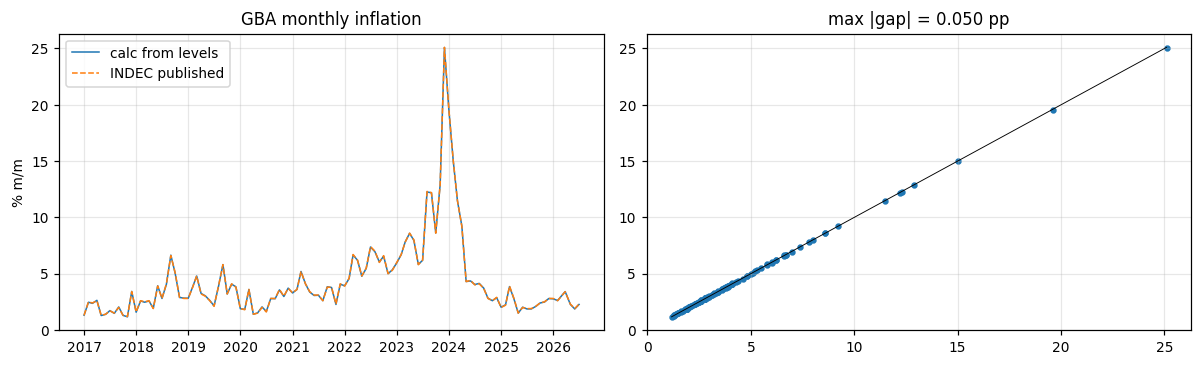

In [10]:
cc = cpi.dropna(subset=["infl_mom_gba", "indec_mom_gba_pct"]).copy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(cc.date, cc.infl_mom_gba, lw=1, label="calc from levels")
ax[0].plot(cc.date, cc.indec_mom_gba_pct, lw=1, ls="--", label="INDEC published")
ax[0].set_title("GBA monthly inflation"); ax[0].set_ylabel("% m/m"); ax[0].legend()
ax[1].scatter(cc.indec_mom_gba_pct, cc.infl_mom_gba, s=10)
lims = [cc[["indec_mom_gba_pct", "infl_mom_gba"]].min().min(),
        cc[["indec_mom_gba_pct", "infl_mom_gba"]].max().max()]
ax[1].plot(lims, lims, "k-", lw=.6)
ax[1].set_title(f"max |gap| = {(cc.infl_mom_gba - cc.indec_mom_gba_pct).abs().max():.3f} pp")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "03_indec_crosscheck.png"); plt.show()

## D3 · Composite Total vs its components (sanity)

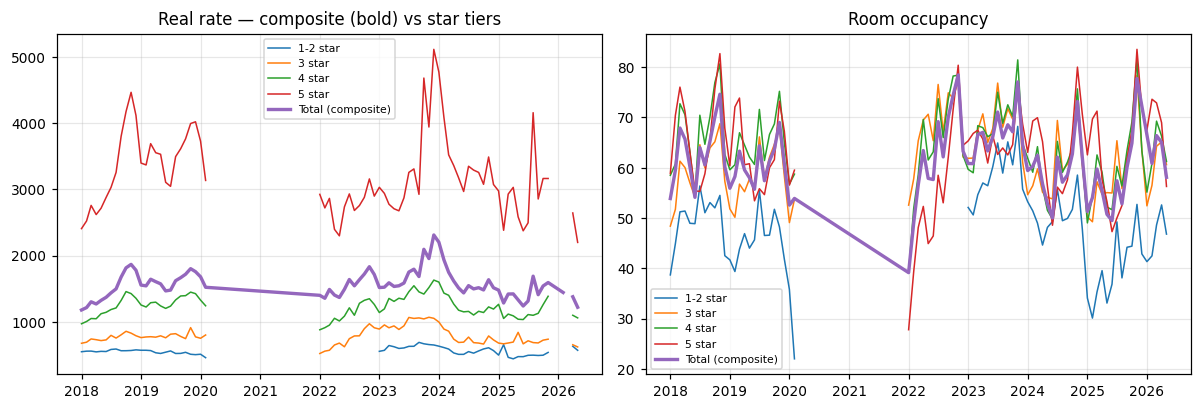

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for cat in C.CORE_CATEGORIES + [C.COMPOSITE_TOTAL]:
    s = wide[(wide.hotel_category == cat) & (wide.in_window == 1)].sort_values("date")
    lw = 2.2 if cat == C.COMPOSITE_TOTAL else 1
    ax[0].plot(s.date, s.real_rate_gba, lw=lw, label=C.CATEGORY_LABELS[cat])
    ax[1].plot(s.date, s.room_occupancy, lw=lw, label=C.CATEGORY_LABELS[cat])
ax[0].set_title("Real rate — composite (bold) vs star tiers"); ax[0].legend(fontsize=7)
ax[1].set_title("Room occupancy"); ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "03_composite_check.png"); plt.show()

In [12]:
LOG.flush()
print("03_merge complete.")

03_merge complete.
